# Arithmetic Square-Wave Sweep — GPU Power Response

This notebook drives a GPU with an *arithmetic square wave*: alternating
hot (compute-heavy) and cold (idle) phases at a fixed frequency. By
sweeping the phase length across orders of magnitude, we can read off
the GPU power-management loop's **frequency response** directly from
energy-counter telemetry.

**Inputs.** Only `rocm_smi::energy_count:device=*` and quantities derived
from it (instantaneous power per device, combined GPU power across the
node). No clock or throttle telemetry is used.

**Pipeline.**
1. Load the trace ensemble; differentiate energy counters into
   instantaneous power; sum across devices for combined GPU power.
2. Inspect a representative run (cumulative energy + instantaneous power).
3. Time-domain grid across the full cycle-count sweep.
4. Frequency domain: per-run amplitude spectra vs the ideal square-wave
   harmonic stack; summary transfer function.
5. Cycle-folded canonical waveform per run.
6. Aggregate metrics vs phase length.


## 1 · Setup

In [62]:
import os
import re
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from scipy import signal
from scipy.stats import binned_statistic
from scipy.optimize import minimize_scalar

from ampere import (
    Ensemble, Metric, MetricConfig, MetricType,
    connect, set_backend, ak,
)

set_backend('pandas')
connect(server="localhost", port=5555)

# --- Cosmetic defaults applied once for the whole notebook ---
plt.rcParams.update({
    'figure.dpi':         110,
    'savefig.dpi':        140,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'axes.labelsize':     11,
    'axes.titlesize':     12,
    'axes.grid':          True,
    'grid.alpha':         0.22,
    'grid.linestyle':     '--',
    'grid.linewidth':     0.7,
    'font.size':          11,
    'legend.frameon':     False,
    'legend.fontsize':    9,
})

# --- Constants (no clock-related thresholds — energy-only analysis) ---
TDP        = 560      # W, MI300A nominal
GPU_DEVICES = (0, 2, 4, 6)


Pandas backend active — skipping Arkouda connection.


## 2 · Load traces and derive power metrics

Each run is one trace directory named `cycles-N`, where `N` is the
number of hot/cold cycles packed into a fixed wall-clock window. The
metric pipeline:

```
energy_count[J]  ─d/dt→  inst_power[W]  ─sum devices→  combined_gpu_power[W]
```


In [63]:
TRACE_ROOT = "/Users/hom/Documents/ampere/examples/arithmetic-square-wave-04-29-26-13:50:09"
TRACES = sorted(
    glob(os.path.join(TRACE_ROOT, "cycles-*")),
    key=lambda s: int(s.rsplit('-', 1)[-1]),
)

# Convert OTF2 → CSV on first run only
for trace in TRACES:
    if not glob(os.path.join(trace, "*.csv")):
        os.system(f"cd {trace} && ~/otf2csv ./traces.otf2")

configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}
ensemble = Ensemble.from_trace_paths(TRACES, {"Node0": ["Process"]}, configs)

cycle_counts = [int(t.rsplit('-', 1)[-1]) for t in TRACES]
N_RUNS = len(cycle_counts)
print(f"Loaded {N_RUNS} runs:  cycles ∈ [{min(cycle_counts)}, {max(cycle_counts)}]")


Loading Runs: 100%|██████████| 32/32 [00:00<00:00, 63.48it/s]

Loaded 32 runs:  cycles ∈ [1, 5040]


In [64]:
def differentiate_energy(energy_metric):
    """Forward-difference an energy counter (J) into instantaneous power (W).
    Negative slopes (counter rollover) and zero-dt intervals are clipped to 0."""
    t, e = energy_metric.times, energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    p = de / dt
    p = ak.where((p < 0) | (dt <= 0), 0.0, p)
    return Metric("power", t[1:], p, MetricConfig(MetricType.INSTANTANEOUS))


def sum_power(*metrics):
    """Element-wise sum of power metrics on the shortest common time grid."""
    L = min(len(m.times) for m in metrics)
    times = min((m.times for m in metrics), key=len)
    values = np.sum([np.asarray(m.values)[:L] for m in metrics], axis=0)
    return Metric('combined_gpu_power', times, values,
                  MetricConfig(MetricType.INSTANTANEOUS))


for d in GPU_DEVICES:
    ensemble.add_derived_metric(
        f"A2rocm_smi:::inst_power:device={d}",
        differentiate_energy,
        f"A2rocm_smi:::energy_count:device={d}",
    )

ensemble.add_derived_metric(
    "A2rocm_smi:::combined_gpu_power",
    sum_power,
    *(f"A2rocm_smi:::inst_power:device={d}" for d in GPU_DEVICES),
)


Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...
Deriving metric 'A2rocm_smi:::combined_gpu_power'...


## 3 · Helpers and per-run cache

A small extraction helper plus a one-time pull of every run's combined
GPU power and per-device power into NumPy arrays. Every plot below
reads from these caches.


In [65]:
PALETTE = plt.cm.plasma(np.linspace(0.12, 0.88, N_RUNS))


def extract(metric):
    """Metric → (t, y) NumPy arrays."""
    return np.asarray(metric.times), np.asarray(metric.values)


# Cache: per-run combined GPU power and per-device power
combined_power = []   # list of (t, p) tuples, one per run
device_power   = {d: [] for d in GPU_DEVICES}
node_power     = []

for run in ensemble.runs:
    # node_power.append(extract(run.nodes[0].metrics["A2coretemp:::craypm:power"]))
    combined_power.append(extract(run.nodes[0].metrics["A2rocm_smi:::combined_gpu_power"]))
    for d in GPU_DEVICES:
        device_power[d].append(extract(run.nodes[0].metrics[f"A2rocm_smi:::inst_power:device={d}"]))


def f0_of(i):
    """Drive fundamental frequency for run i (Hz)."""
    t, _ = combined_power[i]
    return cycle_counts[i] / (t[-1] - t[0])


## 4 · Single-run anatomy

Energy is the integral; instantaneous power is its slope. The two
panels below show both for one representative run, side-by-side, so the
relationship is obvious before we move on.


In [66]:
# PROBE = 23

# t_e, e = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=4"])
# e = e - e[0]
# t_p, p = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2coretemp:::craypm:accel2_power"])

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
#                                gridspec_kw=dict(height_ratios=[1, 1.4]))

# ax1.plot(t_e, e, color='#1565C0', lw=2)
# ax1.fill_between(t_e, e, alpha=0.10, color='#1565C0')
# ax1.set_ylabel("Cumulative energy (J)\ndevice 0")
# ax1.set_title(f"Single-run anatomy — cycles-{cycle_counts[PROBE]}",
#               loc='left')

# ax2.plot(t_p, p, color='#C62828', lw=1, alpha=0.85)
# ax2.axhline(TDP * len(GPU_DEVICES), color='black', lw=0.8, ls='--', alpha=0.6,
#             label=f"Combined GPU TDP  ({TDP * len(GPU_DEVICES)} W)")
# ax2.set_ylabel("Combined GPU\npower (W)")
# ax2.set_xlabel("Time (s)")
# ax2.legend(loc='upper right')
# ax2.set_ylim(0)

# for ax in (ax1, ax2):
#     ax.xaxis.set_minor_locator(AutoMinorLocator())

# plt.tight_layout()
# plt.show()


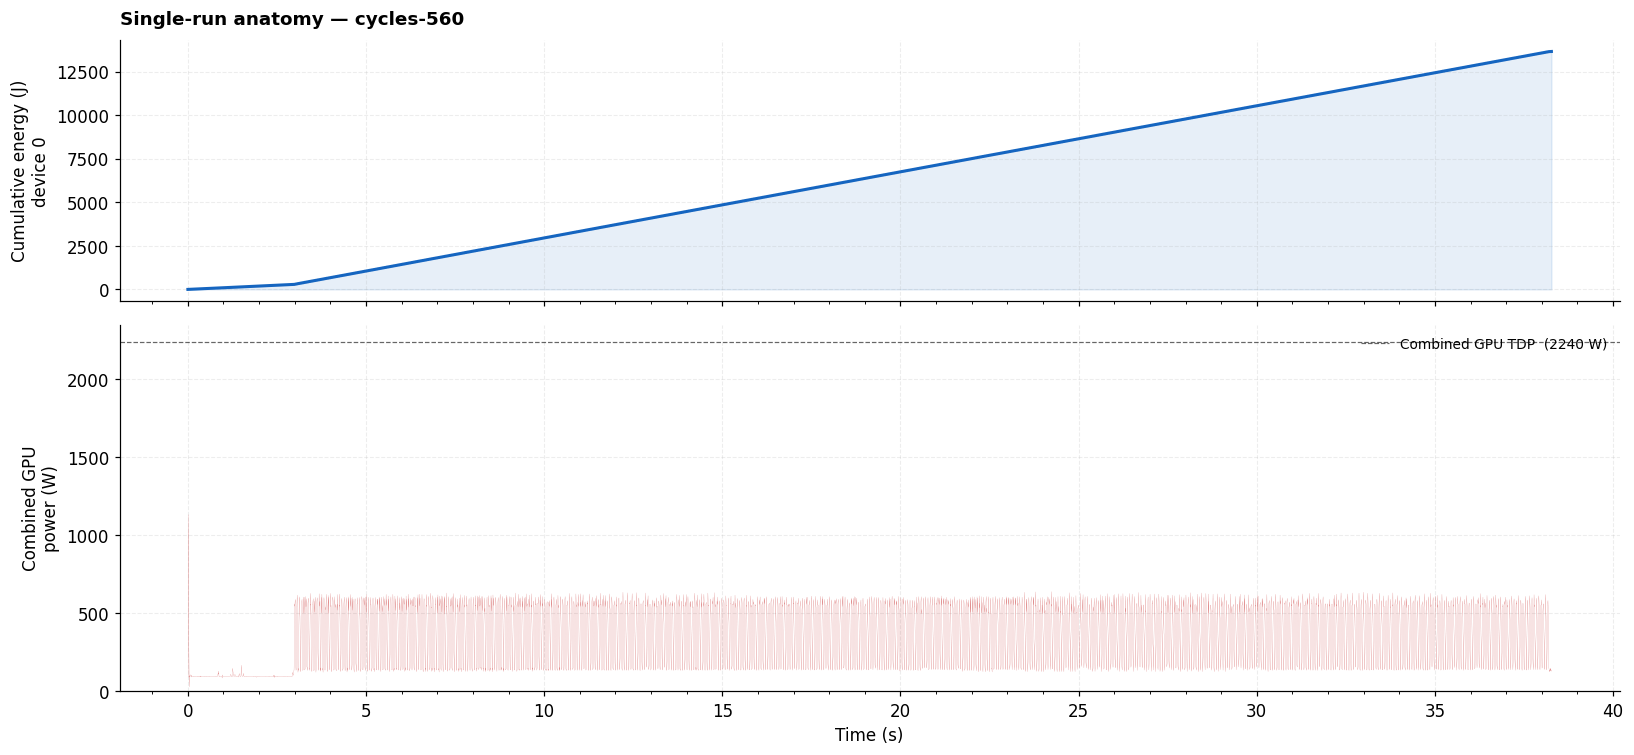

In [67]:
PROBE = 23

t_e, e = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=4"])
e = e - e[0]
t_p, p = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::inst_power:device=4"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1.4]))

ax1.plot(t_e, e, color='#1565C0', lw=2)
ax1.fill_between(t_e, e, alpha=0.10, color='#1565C0')
ax1.set_ylabel("Cumulative energy (J)\ndevice 0")
ax1.set_title(f"Single-run anatomy — cycles-{cycle_counts[PROBE]}",
              loc='left')

ax2.plot(t_p, p, color='#C62828', lw=0.1, alpha=0.85)
ax2.axhline(TDP * len(GPU_DEVICES), color='black', lw=0.8, ls='--', alpha=0.6,
            label=f"Combined GPU TDP  ({TDP * len(GPU_DEVICES)} W)")
ax2.set_ylabel("Combined GPU\npower (W)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right')
ax2.set_ylim(0)

for ax in (ax1, ax2):
    ax.xaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.show()


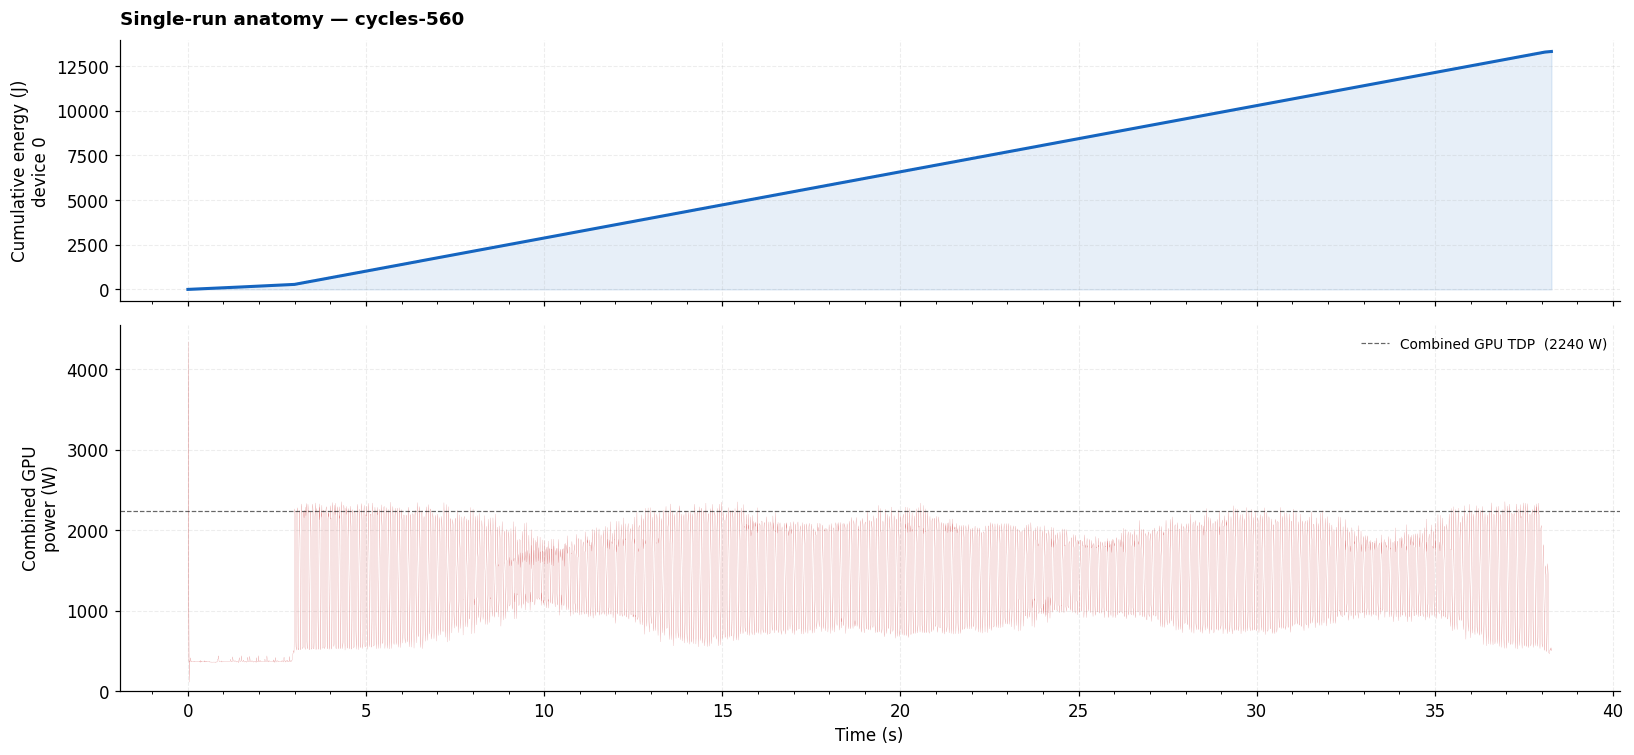

In [68]:
PROBE = 23

t_e, e = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=0"])
e = e - e[0]
t_p, p = device_power[4][PROBE]
t_p, p = combined_power[PROBE]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1.4]))

ax1.plot(t_e, e, color='#1565C0', lw=2)
ax1.fill_between(t_e, e, alpha=0.10, color='#1565C0')
ax1.set_ylabel("Cumulative energy (J)\ndevice 0")
ax1.set_title(f"Single-run anatomy — cycles-{cycle_counts[PROBE]}",
              loc='left')

ax2.plot(t_p, p, color='#C62828', lw=0.1, alpha=0.85)
ax2.axhline(TDP * len(GPU_DEVICES), color='black', lw=0.8, ls='--', alpha=0.6,
            label=f"Combined GPU TDP  ({TDP * len(GPU_DEVICES)} W)")
ax2.set_ylabel("Combined GPU\npower (W)")
ax2.set_xlabel("Time (s)")
ax2.legend(loc='upper right')
ax2.set_ylim(0)

for ax in (ax1, ax2):
    ax.xaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.show()


In [69]:
# PROBE = 23

# t_e, e = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=0"])
# # # e += extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=2"])[1]
# # # e += extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=4"])[1]
# # # e += extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::energy_count:device=6"])[1]
# e = e - e[0]
# # t_p, p = device_power[4][PROBE]
# # t_p, p = node_power[PROBE]

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
#                                gridspec_kw=dict(height_ratios=[1, 1.4]))

# ax1.plot(t_e, e, color='#1565C0', lw=2)
# ax1.fill_between(t_e, e, alpha=0.10, color='#1565C0')
# ax1.set_ylabel("Cumulative energy (J)\ndevice 0")
# ax1.set_title(f"Single-run anatomy — cycles-{cycle_counts[PROBE]}",
#               loc='left')

# t_p, p = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2rocm_smi:::inst_power:device=0"])
# # p /= 1e6
# ax2.scatter(t_p, p, color='#1565C0', lw=0.1, alpha=0.85, s=2)
# t_p, p = extract(ensemble.runs[PROBE].nodes[0].metrics[f"A2coretemp:::craypm:accel0_power"])
# ax2.scatter(t_p, p, color='#C62828', lw=1, alpha=0.85, s=10)
# ax2.axhline(TDP * len(GPU_DEVICES), color='black', lw=0.8, ls='--', alpha=0.6,
#             label=f"Combined GPU TDP  ({TDP * len(GPU_DEVICES)} W)")
# ax2.set_ylabel("Combined GPU\npower (W)")
# ax2.set_xlabel("Time (s)")
# ax2.legend(loc='upper right')
# ax2.set_ylim(0)

# for ax in (ax1, ax2):
#     ax.xaxis.set_minor_locator(AutoMinorLocator())

# plt.tight_layout()
# plt.show()


## 5 · Cycle sweep — time domain

A small-multiples grid: every run, same y-axis, colored by sweep
position so the trend across cycle counts is visible at a glance. The
TDP line is marked on every panel.


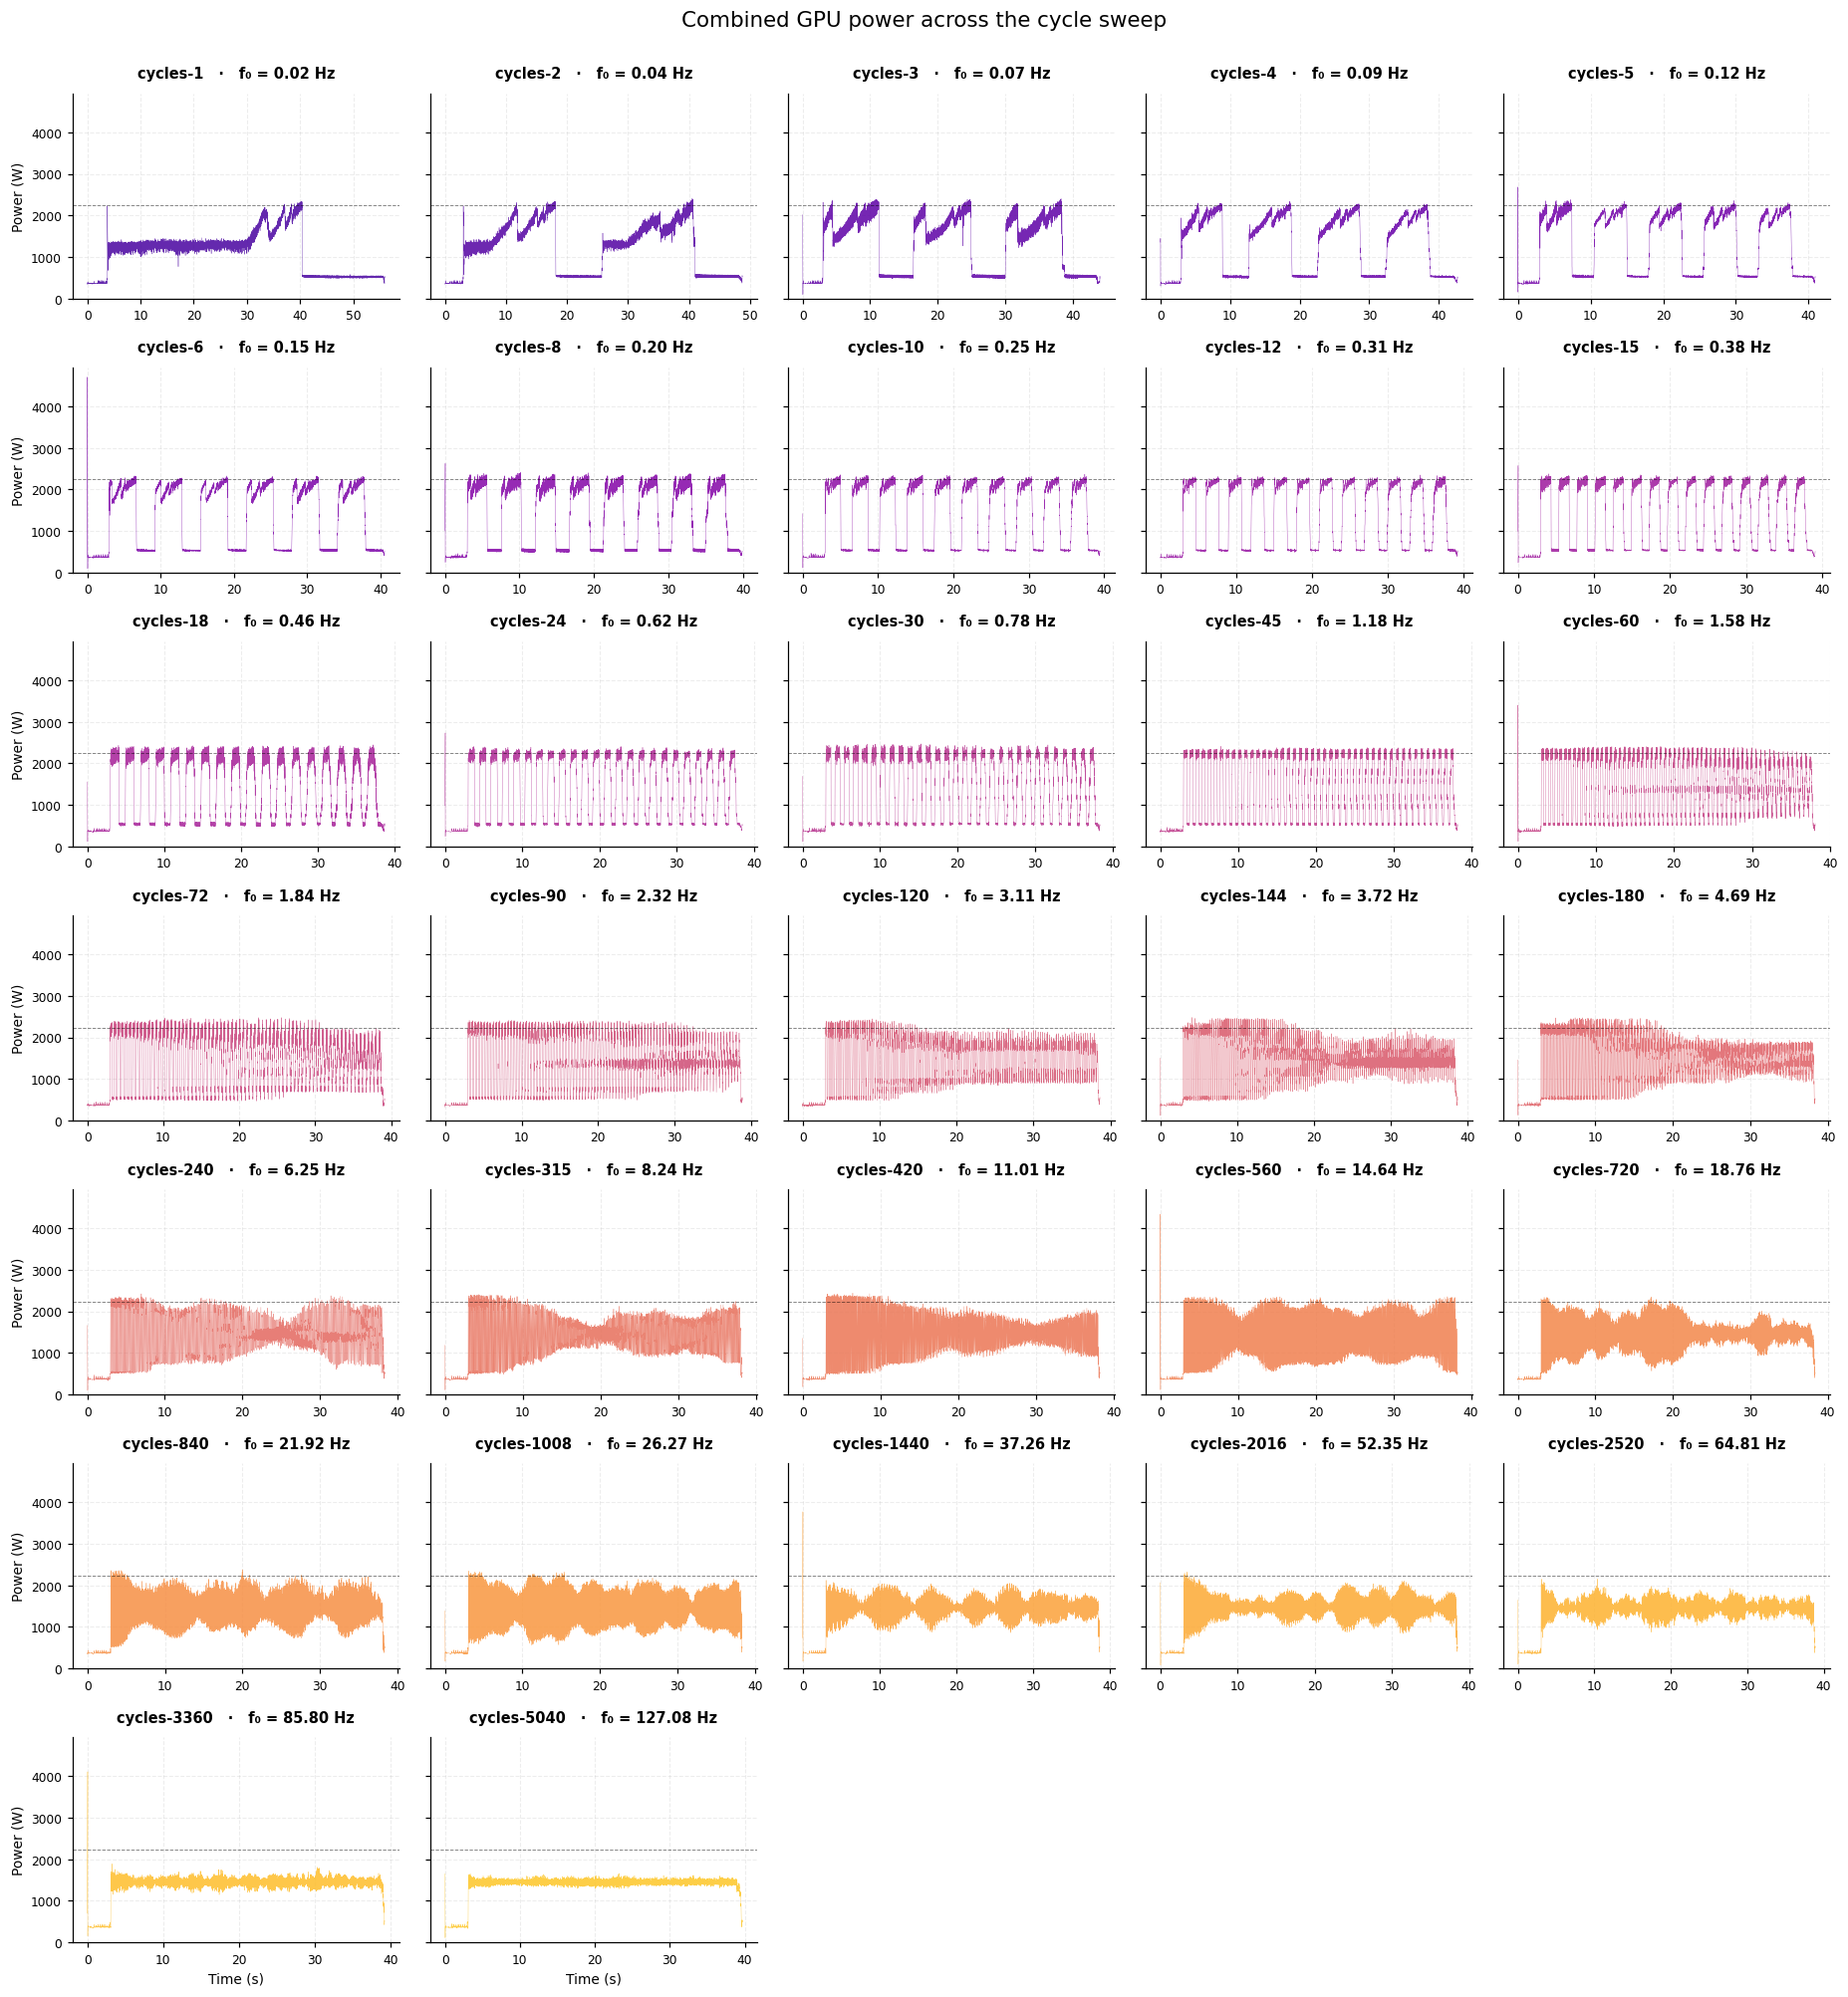

In [70]:
def grid_shape(n, ncols=5):
    return (n + ncols - 1) // ncols, ncols


nrows, ncols = grid_shape(N_RUNS)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.6),
                         sharey=True, sharex=False)
fig.suptitle("Combined GPU power across the cycle sweep",
             fontsize=14, y=1.00)

ymax = max(p.max() for _, p in combined_power) * 1.05
TDP_TOTAL = TDP * len(GPU_DEVICES)

for i, ax in enumerate(axes.flat):
    if i >= N_RUNS:
        ax.set_visible(False); continue
    t, p = combined_power[i]
    ax.plot(t, p, color=PALETTE[i], lw=0.25, alpha=0.85, rasterized=True)
    ax.axhline(TDP_TOTAL, color='black', lw=0.6, ls='--', alpha=0.5)
    ax.set_ylim(0, ymax)
    ax.set_title(f"cycles-{cycle_counts[i]}   ·   f₀ = {f0_of(i):.2f} Hz",
                 fontsize=9.5)
    ax.tick_params(labelsize=8)
    if i % ncols == 0:
        ax.set_ylabel("Power (W)", fontsize=9)
    if i // ncols == nrows - 1:
        ax.set_xlabel("Time (s)", fontsize=9)

plt.tight_layout()
plt.show()


In [71]:
# def grid_shape(n, ncols=5):
#     return (n + ncols - 1) // ncols, ncols


# nrows, ncols = grid_shape(N_RUNS)
# fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.6),
#                          sharey=True, sharex=False)
# fig.suptitle("Combined GPU power across the cycle sweep",
#              fontsize=14, y=1.00)

# ymax = max(p.max() for _, p in node_power) * 1.05
# TDP_TOTAL = TDP * len(GPU_DEVICES)

# for i, ax in enumerate(axes.flat):
#     if i >= N_RUNS:
#         ax.set_visible(False); continue
#     # t, p = node_power[i]
#     t, p = extract(ensemble.runs[i].nodes[0].metrics[f"A2coretemp:::craypm:accel2_power"])
#     ax.plot(t, p, color=PALETTE[i], lw=0.5, alpha=0.85, rasterized=True)
#     ax.axhline(TDP_TOTAL, color='black', lw=0.6, ls='--', alpha=0.5)
#     ax.set_ylim(0, ymax)
#     ax.set_title(f"cycles-{cycle_counts[i]}   ·   f₀ = {f0_of(i):.2f} Hz",
#                  fontsize=9.5)
#     ax.tick_params(labelsize=8)
#     if i % ncols == 0:
#         ax.set_ylabel("Power (W)", fontsize=9)
#     if i // ncols == nrows - 1:
#         ax.set_xlabel("Time (s)", fontsize=9)

# plt.tight_layout()
# plt.show()


## 6 · Frequency domain

A square wave has Fourier series $a_k = 4A/(\pi k)$ at $f_k = k f_0$
for odd $k$. Plotting the measured spectrum against this ideal
harmonic stack on log-log axes makes the GPU's control-loop bandwidth
read straight off the figure: where the measured curve falls below the
ideal $1/f$ envelope, the loop can no longer track the drive.


In [72]:
def amplitude_spectrum(t, p, t_skip_head=3.0, t_skip_tail=1.0,
                       fs_max=500.0, dt=None):
    """Single-sided amplitude spectrum of an irregularly-sampled power trace.

    Crops warmup/cooldown, resamples to a uniform grid, linearly detrends
    (kills DC and any thermal drift), Hann-windows, and returns peak-
    amplitude-scaled magnitudes (W) so an ideal sinusoid of amplitude A
    appears as a tone at value A."""
    t, p = np.asarray(t, float), np.asarray(p, float)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, p = t[m], p[m]
    if len(t) < 64:
        return np.array([]), np.array([])
    if dt is None:
        dt = np.median(np.diff(t))
    fs = min(1.0 / dt, fs_max)
    tu = np.arange(t[0], t[-1], 1.0 / fs)
    pu = np.interp(tu, t, p)
    pd = signal.detrend(pu, type='linear')
    w  = signal.windows.hann(len(pd))
    spec = np.fft.rfft(pd * w)
    freq = np.fft.rfftfreq(len(pd), 1.0 / fs)
    mag = (2.0 / w.sum()) * np.abs(spec)
    return freq, mag


def square_wave_amplitude(t, p, t_skip_head=3.0, t_skip_tail=1.0):
    """Robust half peak-to-peak from cropped trace (5/95 percentiles)."""
    t, p = np.asarray(t, float), np.asarray(p, float)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    p = p[m]
    if len(p) < 64:
        return 0.0
    return 0.5 * (np.percentile(p, 95) - np.percentile(p, 5))


def ideal_square_harmonics(f0, A, n_odd=15, f_max=500.0):
    ks = np.arange(1, 2 * n_odd, 2)
    f = ks * f0
    a = 4.0 * A / (np.pi * ks)
    keep = (f > 0) & (f <= f_max)
    return f[keep], a[keep], ks[keep]


def measured_at(freq, mag, f_target, half_window=2):
    idx = int(np.argmin(np.abs(freq - f_target)))
    lo, hi = max(0, idx - half_window), min(len(mag), idx + half_window + 1)
    return mag[lo:hi].max()


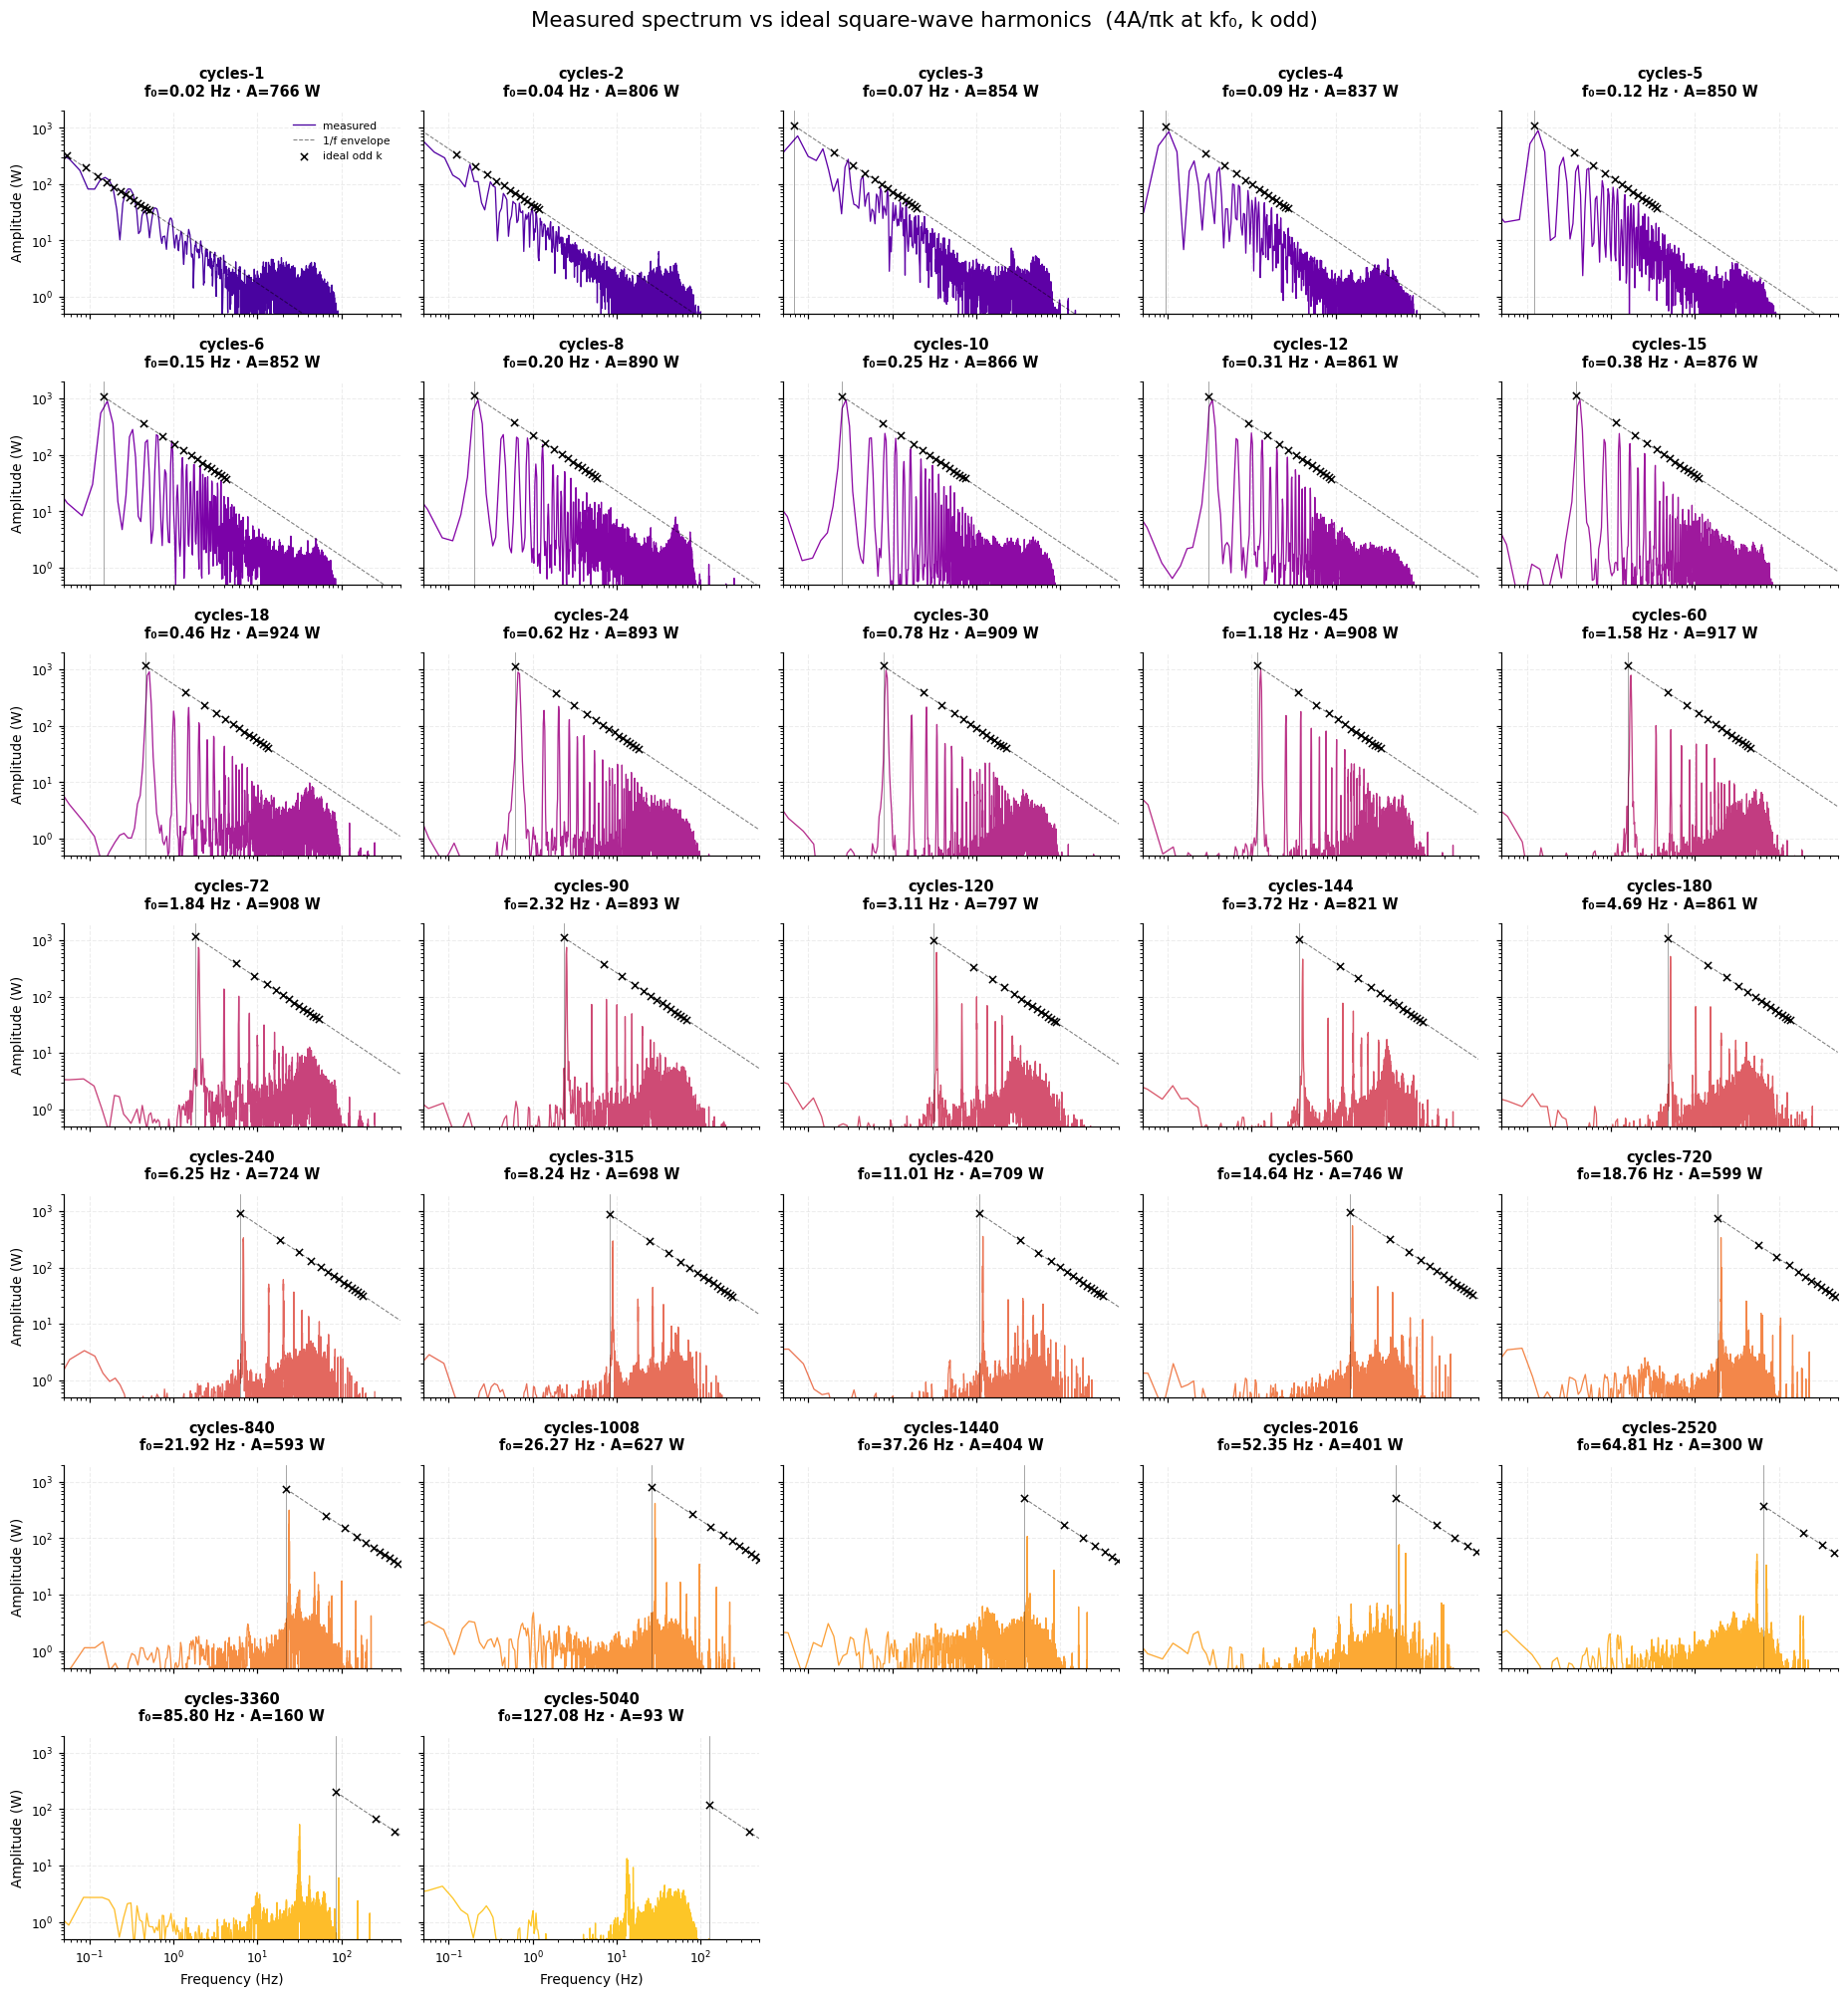

In [73]:
nrows, ncols = grid_shape(N_RUNS)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.6),
                         sharex=True, sharey=True)
fig.suptitle("Measured spectrum vs ideal square-wave harmonics  (4A/πk at kf₀, k odd)",
             fontsize=14, y=1.00)

for i, ax in enumerate(axes.flat):
    if i >= N_RUNS:
        ax.set_visible(False); continue
    t, p = combined_power[i]
    f0   = f0_of(i)
    fg, mg = amplitude_spectrum(t, p, fs_max=500.0, dt=0.001)
    A      = square_wave_amplitude(t, p)

    if len(fg):
        ax.loglog(fg[1:], mg[1:], color=PALETTE[i], lw=0.85,
                  label='measured')

    if A > 0:
        fk, ak, _ = ideal_square_harmonics(f0, A, f_max=500)
        envF = np.array([f0, 500.0])
        envA = (4.0 * A / np.pi) * (f0 / envF)
        ax.loglog(envF, envA, color='black', ls='--', lw=0.7, alpha=0.5,
                  label='1/f envelope')
        ax.scatter(fk, ak, marker='x', color='black', s=22, lw=1.0,
                   zorder=5, label='ideal odd k')
        ax.axvline(f0, color='black', lw=0.5, alpha=0.45)

    ax.set_title(f"cycles-{cycle_counts[i]}\nf₀={f0:.2f} Hz · A={A:.0f} W",
                 fontsize=9.5)
    ax.set_xlim(0.05, 500)
    ax.set_ylim(0.5, 2000)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')
    if i % ncols == 0:
        ax.set_ylabel("Amplitude (W)", fontsize=9)
    if i // ncols == nrows - 1:
        ax.set_xlabel("Frequency (Hz)", fontsize=9)

plt.tight_layout()
plt.show()


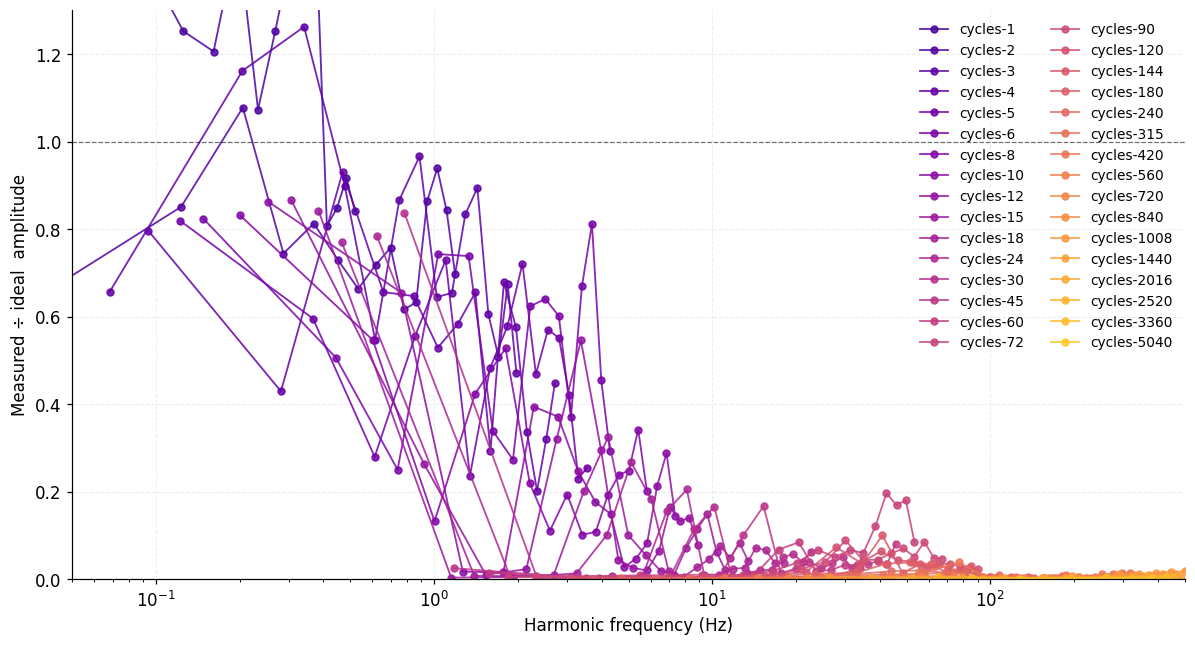

In [74]:
# Per-harmonic transmission ratio: measured / ideal (1.0 = perfect tracking)
fig, ax = plt.subplots(figsize=(11, 6))

for i, (t, p) in enumerate(combined_power):
    f0 = f0_of(i)
    fg, mg = amplitude_spectrum(t, p, fs_max=500.0, dt=0.001)
    A = square_wave_amplitude(t, p)
    if not len(fg) or A <= 0:
        continue
    fk, ak, _ = ideal_square_harmonics(f0, A, f_max=500)
    measured = np.array([measured_at(fg, mg, f) for f in fk])
    ratio = measured / ak
    ax.semilogx(fk, ratio, '-o', color=PALETTE[i], lw=1.2, ms=4.5,
                alpha=0.85, label=f"cycles-{cycle_counts[i]}")

ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.55)
ax.set_xlabel("Harmonic frequency (Hz)")
ax.set_ylabel("Measured ÷ ideal  amplitude")
# ax.set_title()
ax.set_xlim(0.05, 500)
ax.set_ylim(0, 1.3)
ax.legend(ncol=2, loc='upper right')
plt.tight_layout()
plt.show()


## 7 · Cycle-folded canonical waveform

Each run contains many cycles; folding them onto a single canonical
$[0, 1)$ phase axis exposes the average shape of one hot/cold cycle
with confidence bands. Phase 0 is aligned to the cold→hot edge so the
panels are directly comparable across the sweep.


In [75]:

def fold_cycles(t, y, n_cycles, t_skip_head=3.0, t_skip_tail=1.0, n_phase_bins=400):
    """
    Fold N cycles of a periodic signal onto one canonical cycle.
    Optimized to find the best-fit period and prevent phase drift.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, y = t[mask], y[mask]
    
    if len(t) < 64 or n_cycles < 1:
        return None
        
    duration = t[-1] - t[0]
    
    # 1. Estimación inicial del período
    naive_period = duration / n_cycles
    
    # 2. Función objetivo: Maximizar la varianza del perfil plegado
    # Un perfil bien alineado tendrá bordes definidos y alta varianza.
    # Un perfil desfasado se aplanará y tendrá baja varianza.
    def objective(p):
        ph = ((t - t[0]) / p) % 1.0
        # Usamos menos bins (ej. 50) para la optimización para que sea rápido y robusto
        means, _, _ = binned_statistic(ph, y, statistic='mean', bins=50)
        # Queremos maximizar la varianza, por lo que minimizamos su valor negativo
        return -np.nanvar(means)
        
    # 3. Encontrar el período de mejor ajuste (margen de error del ±5%)
    res = minimize_scalar(
        objective, 
        bounds=(naive_period * 0.95, naive_period * 1.05), 
        method='bounded'
    )
    
    best_period = res.x if res.success else naive_period
    
    # 4. Usar el período optimizado para el plegado final
    phase = ((t - t[0]) / best_period) % 1.0
    cycle_id = ((t - t[0]) // best_period).astype(int)
    
    phase_grid = np.linspace(0, 1, n_phase_bins, endpoint=False)
    n_used = max(1, int(cycle_id.max()) + 1) # Asegurar incluir el último ciclo
    stack = np.full((n_used, n_phase_bins), np.nan)
    
    for k in range(n_used):
        sel = cycle_id == k
        if sel.sum() < 4:
            continue
        order = np.argsort(phase[sel])
        ph_k = phase[sel][order]
        y_k = y[sel][order]
        
        _, uniq = np.unique(ph_k, return_index=True)
        if len(uniq) < 4:
            continue
            
        stack[k] = np.interp(phase_grid, ph_k[uniq], y_k[uniq])
        
    if np.all(np.isnan(stack)):
        return None
        
    return dict(
        phase=phase_grid, 
        period_s=best_period, # Período corregido
        stack=stack,
        median=np.nanmedian(stack, axis=0),
        p10=np.nanpercentile(stack, 10, axis=0),
        p25=np.nanpercentile(stack, 25, axis=0),
        p75=np.nanpercentile(stack, 75, axis=0),
        p90=np.nanpercentile(stack, 90, axis=0),
        n_cycles_used=int(np.sum(~np.all(np.isnan(stack), axis=1))),
    )


def align_to_cold_first(folded, min_swing_W=30.0):
    """Roll the folded median so phase 0 lands at the cold→hot edge.
    Uses circular cross-correlation against an ideal square reference."""
    if folded is None:
        return None
    m = folded['median']
    n = len(m)
    swing = float(np.nanmax(m) - np.nanmin(m))
    if swing < min_swing_W or n < 8:
        return {**folded, 'phase_shift': 0, 'align_quality': 0.0,
                'detected_swing_W': swing}

    centered = np.nan_to_num(m, nan=np.nanmean(m))
    centered = centered - centered.mean()
    half = n // 2
    ref = np.concatenate([-np.ones(half), np.ones(n - half)])
    corr = np.real(np.fft.ifft(np.fft.fft(centered) * np.conj(np.fft.fft(ref))))
    lag = int(np.argmax(corr))
    quality = float(corr[lag] / np.abs(centered).sum()) if np.abs(centered).sum() else 0.0

    out = dict(folded)
    for key in ('median', 'p10', 'p90'):
        out[key] = np.roll(folded[key], -lag)
    out['stack'] = np.roll(folded['stack'], -lag, axis=1)
    out['phase_shift']      = lag
    out['align_quality']    = quality
    out['detected_swing_W'] = swing
    return out


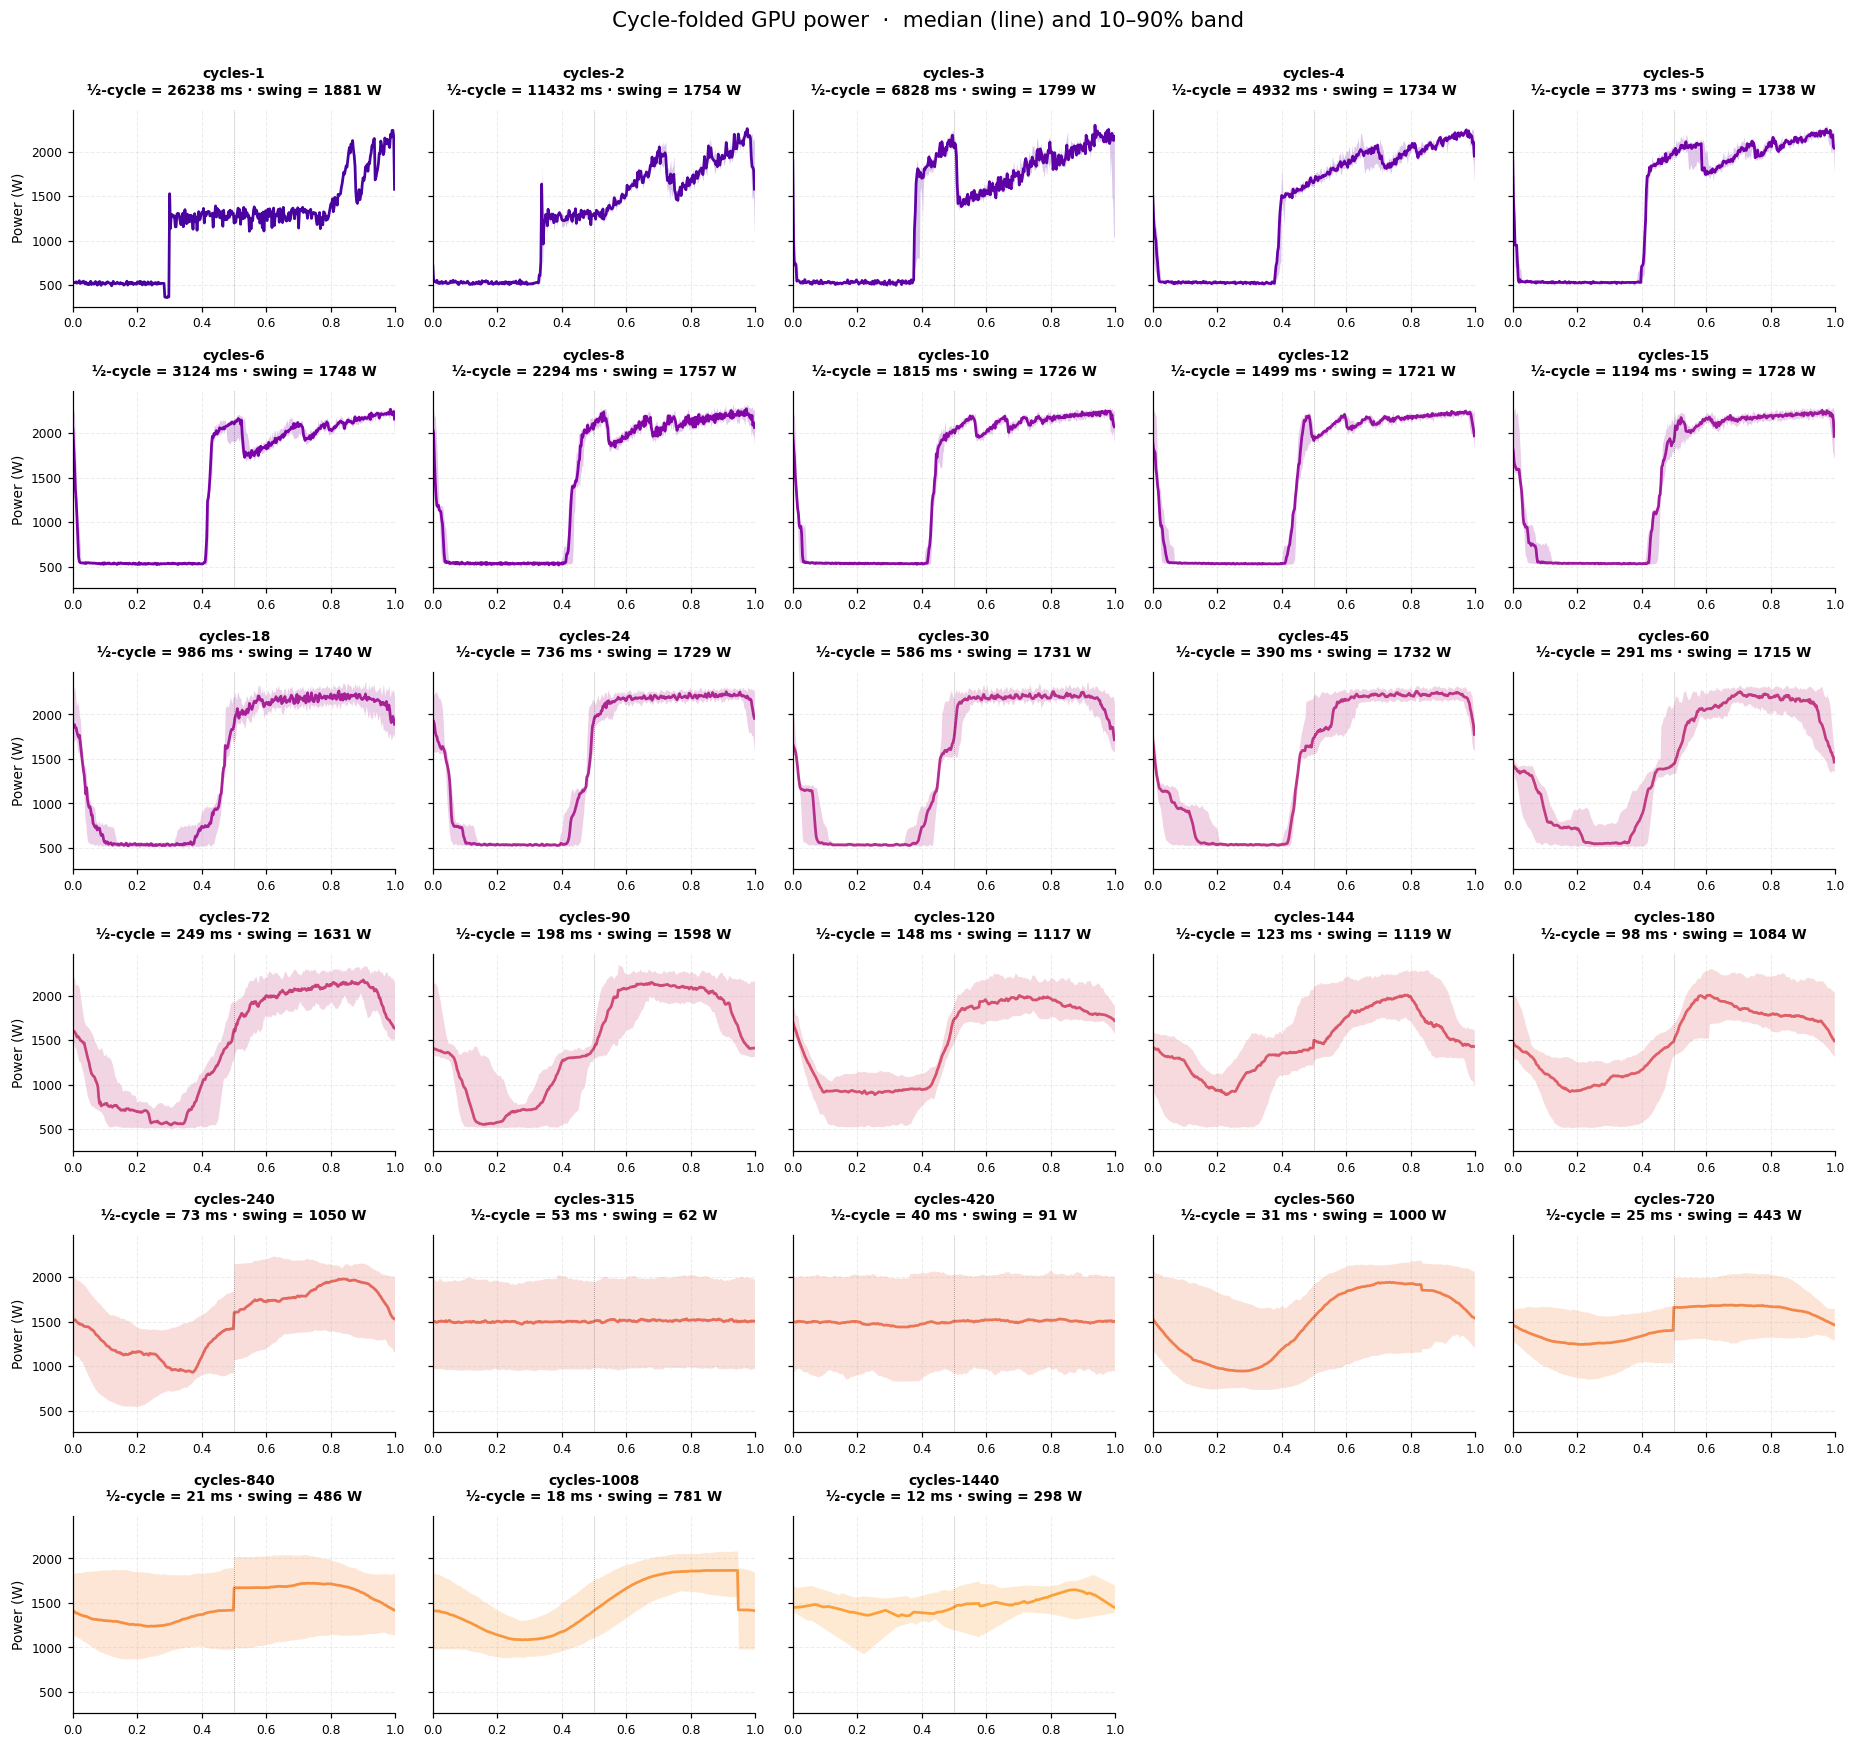

In [76]:
nrows, ncols = grid_shape(N_RUNS)
fig, axes = plt.subplots(nrows, ncols, figsize=(17, nrows * 2.6), sharey=True)
fig.suptitle("Cycle-folded GPU power  ·  median (line) and 10–90% band",
             fontsize=14, y=1.00)

for i, ax in enumerate(axes.flat):
    if i >= N_RUNS:
        ax.set_visible(False); continue
    t, p = combined_power[i]
    fold = align_to_cold_first(fold_cycles(t, p, cycle_counts[i]))
    if fold is None:
        ax.set_visible(False); continue

    ax.fill_between(fold['phase'], fold['p10'], fold['p90'],
                    color=PALETTE[i], alpha=0.22, lw=0)
    ax.plot(fold['phase'], fold['median'], color=PALETTE[i], lw=1.8)
    ax.axvline(0.5, color='black', lw=0.5, ls=':', alpha=0.45)

    half_ms = fold['period_s'] * 500
    ax.set_title(f"cycles-{cycle_counts[i]}\n"
                 f"½-cycle = {half_ms:.0f} ms · "
                 f"swing = {fold['detected_swing_W']:.0f} W",
                 fontsize=9)
    ax.set_xlim(0, 1)
    ax.tick_params(labelsize=8)
    if i % ncols == 0:
        ax.set_ylabel("Power (W)", fontsize=9)
    if i // ncols == nrows - 1:
        ax.set_xlabel("Phase  (0 = cold start, 0.5 = hot start)", fontsize=9)

plt.tight_layout()
plt.show()


## 8 · Aggregate metrics vs phase length

Four scalars per run, each plotted against the half-cycle length in
milliseconds:

* **Mean combined GPU power** — bulk energy demand of the run.
* **Fraction of time above TDP** — how often the loop overshoots.
* **Mean excess power above TDP** — by how much, when it does.
* **Cycle swing (peak-to-peak)** — the actual transmitted square-wave
  amplitude, falling off as the loop fails to track fast phases.

All four are plotted on a shared log-x axis, so you can read the
turn-over points off the figures directly.


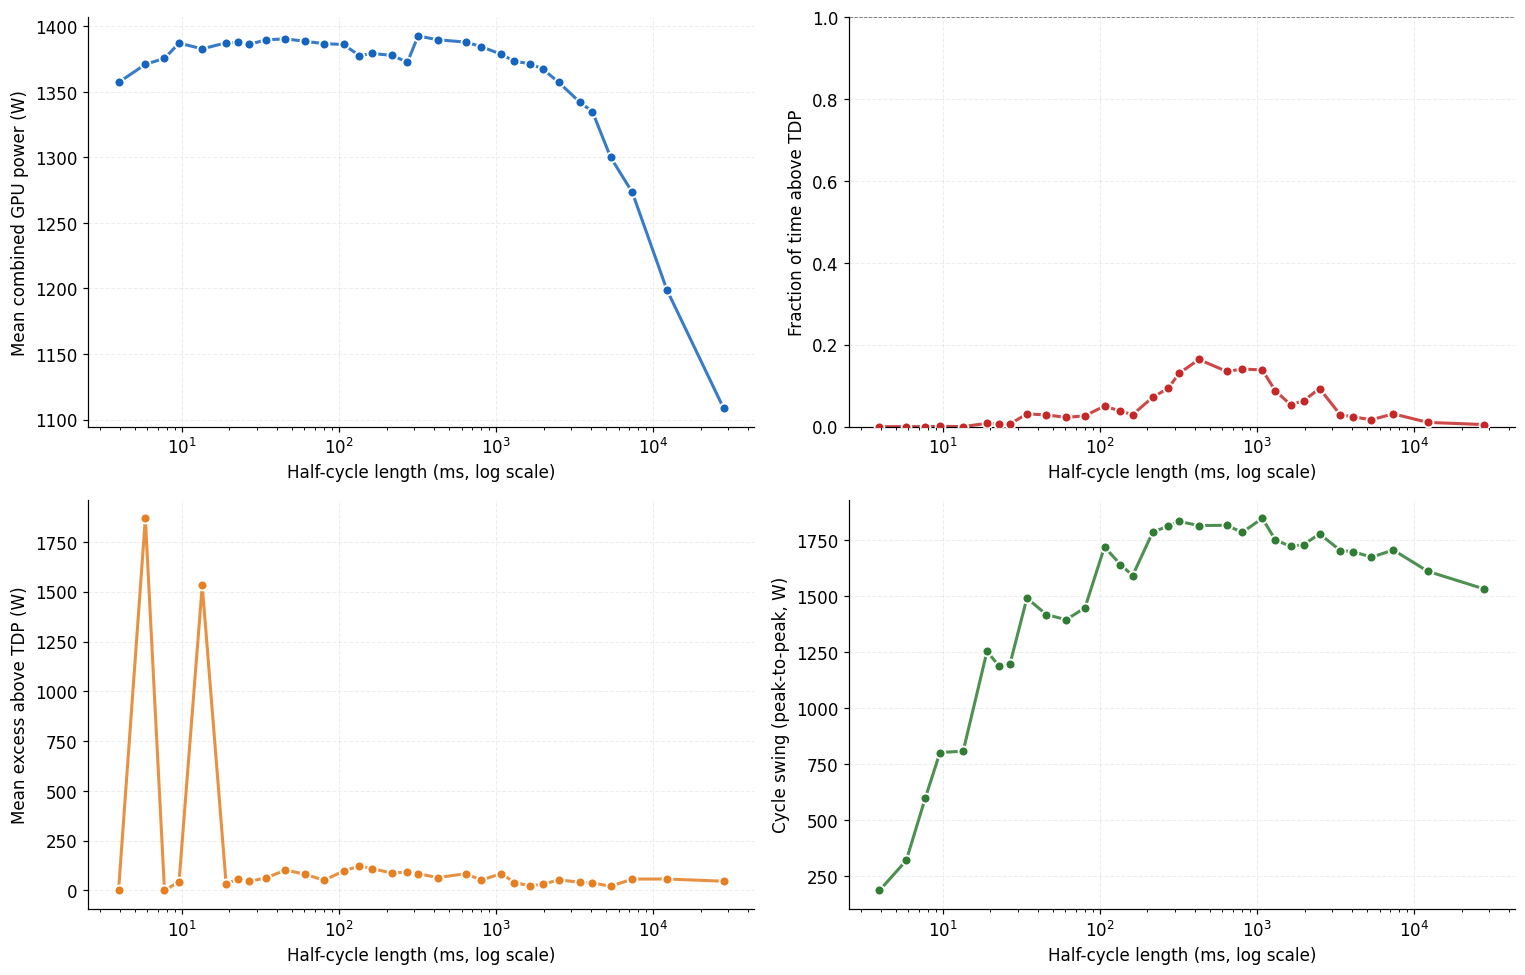

In [78]:
half_period_ms = []
mean_power     = []
frac_above_tdp = []
excess_above   = []
cycle_swing    = []
TDP_TOTAL = TDP * len(GPU_DEVICES)

for i, (t, p) in enumerate(combined_power):
    duration = t[-1] - t[0]
    half_period_ms.append(1000 * duration / (2 * cycle_counts[i]))
    mean_power.append(float(p.mean()))
    above = p > TDP_TOTAL
    frac_above_tdp.append(float(above.mean()))
    excess_above.append(float(p[above].mean() - TDP_TOTAL) if above.any() else 0.0)
    cycle_swing.append(2 * square_wave_amplitude(t, p))

half_period_ms = np.array(half_period_ms)
order = np.argsort(half_period_ms)


def lineplot(ax, y, ylabel, color, ylim=None, fmt='{:.0f}'):
    x = half_period_ms[order]; y = np.array(y)[order]
    ax.plot(x, y, '-', color=color, lw=2.0, alpha=0.85, zorder=2)
    ax.scatter(x, y, color=color, s=42, edgecolor='white', lw=1.2, zorder=3)
    ax.set_xscale('log')
    ax.set_xlabel("Half-cycle length (ms, log scale)")
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.xaxis.set_major_locator(plt.LogLocator(base=10, numticks=8))


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# fig.suptitle("How does the GPU respond as the drive period changes?",
#              fontsize=14, y=1.00)

lineplot(axes[0, 0], mean_power,    "Mean combined GPU power (W)", '#1565C0')
lineplot(axes[0, 1], frac_above_tdp,"Fraction of time above TDP",  '#C62828', ylim=(0, 1))
lineplot(axes[1, 0], excess_above,  "Mean excess above TDP (W)",   '#E67E22')
lineplot(axes[1, 1], cycle_swing,   "Cycle swing (peak-to-peak, W)",'#2E7D32')

axes[0, 1].axhline(1.0, color='black', lw=0.6, ls='--', alpha=0.5)

plt.tight_layout()
plt.show()
